# 02 Exploratory Data Analysis

This notebook performs the core exploratory analysis for the climate change project. Each section is written to make the analysis easy to follow during checking, viva, and report writing.

## Objectives

- inspect summary statistics
- study missing-value patterns
- understand temperature distribution
- analyze long-term global warming trends
- compare regions and countries
- inspect correlations among engineered features

## EDA Scope Note

This notebook uses the full cleaned dataset where that is most important for correctness, and large random samples where full plotting would be unnecessarily heavy for routine analysis.

- Full cleaned dataset: summary statistics, missing-value counts, yearly global trend, and global vs South Asia trend.
- Large sampled visualizations: histogram, seasonal boxplot, country comparison, outlier inspection, and correlation heatmap.

This keeps the analysis fair, representative, and practical to run.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

from pathlib import Path


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "data").exists() or (candidate / "climate_change_prediction_dataset.csv").exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed" if (DATA_DIR / "processed").exists() else PROJECT_ROOT
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables" if (OUTPUTS_DIR / "tables").exists() else PROJECT_ROOT
MODELS_DIR = OUTPUTS_DIR / "models"
RAW_DATASET_PATH = RAW_DIR / "GlobalLandTemperaturesByCity.csv"
if not RAW_DATASET_PATH.exists() and (PROJECT_ROOT / "climate_change_prediction_dataset.csv").exists():
    RAW_DATASET_PATH = PROJECT_ROOT / "climate_change_prediction_dataset.csv"

def load_temperature_data(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"Dataset not found at {csv_path}")
    return pd.read_csv(csv_path)


## Load Prepared Data

The notebook uses the processed CSV files created in the preprocessing stage. A memory-safe read is used so the notebook remains stable on the local machine.

In [2]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

missing_values = pd.read_csv(TABLES_DIR / 'missing_values_summary.csv')
summary_stats = pd.read_csv(TABLES_DIR / 'summary_statistics.csv')

cleaned_columns = [
    'dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Year', 'Month', 'Season',
    'Country', 'RegionTag', 'LatitudeValue', 'LongitudeValue', 'Lag1Temperature',
    'Lag12Temperature', 'Rolling12MeanTemperature', 'HistoricalCityMonthMean',
    'TemperatureAnomaly', 'ClimateRiskIndex', 'City'
]
cleaned_df = pd.read_csv(
    PROCESSED_DIR / 'cleaned_temperature_data.csv',
    usecols=cleaned_columns,
    parse_dates=['dt']
)
south_asia_df = pd.read_csv(
    PROCESSED_DIR / 'south_asia_subset.csv',
    usecols=['dt', 'AverageTemperature', 'Year', 'Country', 'City'],
    parse_dates=['dt']
)

print('Cleaned shape:', cleaned_df.shape)
print('South Asia shape:', south_asia_df.shape)

Cleaned shape: (4788080, 17)
South Asia shape: (672452, 5)


## Summary Statistics

This table gives the basic central tendency and spread of the main climate variables used in the project.

In [3]:
summary_stats

,Unnamed: 0,AverageTemperature,AverageTemperatureUncertainty,TemperatureAnomaly
0,count,4.788080e+06,4.788080e+06,4.746704e+06
1,mean,1.782904e+01,4.433061e-01,2.623021e-01
2,std,1.003360e+01,2.713149e-01,1.618167e+00
3,min,-4.270400e+01,3.400000e-02,-3.094400e+01
4,25%,1.207200e+01,2.690000e-01,-3.459001e-01
5,50%,2.020700e+01,3.720000e-01,2.495222e-01
6,75%,2.580300e+01,5.350000e-01,8.778994e-01
7,max,3.915600e+01,7.568000e+00,3.270300e+01


## Missing Values Overview

This helps explain which raw columns needed attention before modeling.

In [4]:
missing_values

,Column,MissingValues
0,AverageTemperature,364130
1,AverageTemperatureUncertainty,364130
2,dt,0
3,City,0
4,Country,0
5,Latitude,0
6,Longitude,0


## Missing Values Chart

The chart below visually highlights where the raw dataset was incomplete. These counts come from the full raw dataset.

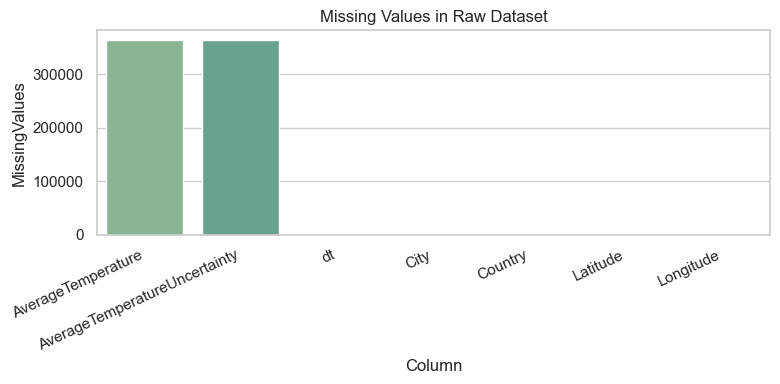

In [5]:
plt.figure(figsize=(8, 4))
sns.barplot(data=missing_values, x='Column', y='MissingValues', hue='Column', palette='crest', legend=False)
plt.xticks(rotation=25, ha='right')
plt.title('Missing Values in Raw Dataset')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_values_chart.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: Missing values are concentrated mainly in the temperature and uncertainty columns. This justifies explicit cleaning before model training.

## Temperature Distribution

This histogram shows the overall spread of the target variable across cities and time. A large random sample is used here because plotting every row is unnecessarily heavy.

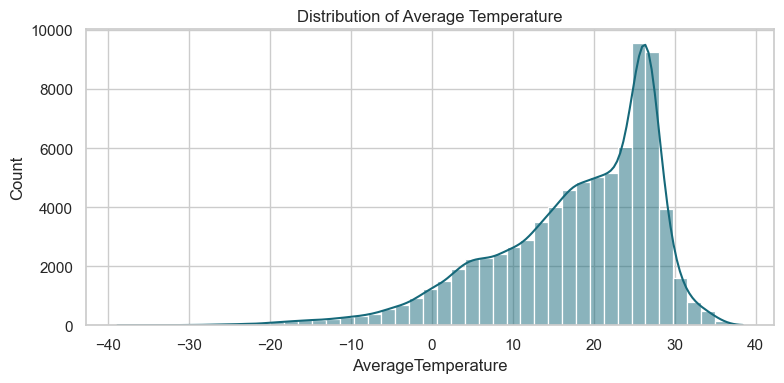

In [6]:
distribution_sample = cleaned_df.sample(n=min(80000, len(cleaned_df)), random_state=42)
plt.figure(figsize=(8, 4))
sns.histplot(distribution_sample['AverageTemperature'], bins=45, kde=True, color='#16697A')
plt.title('Distribution of Average Temperature')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temperature_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: The target variable is broadly distributed because the dataset mixes cold and warm cities from many geographic regions.

## Global Trend Over Time

This line plot helps identify long-term warming patterns in the global aggregate. The yearly means in this section are calculated from the full cleaned dataset.

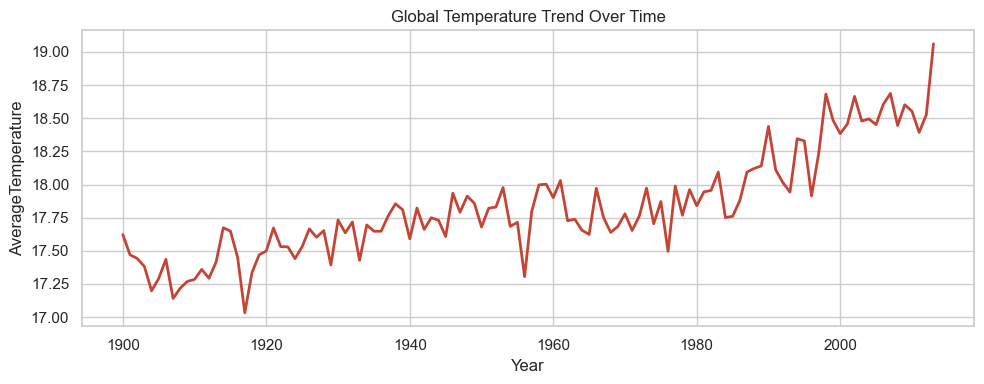

In [7]:
yearly_global = cleaned_df.groupby('Year', observed=True)['AverageTemperature'].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.lineplot(data=yearly_global, x='Year', y='AverageTemperature', color='#C44536', linewidth=2)
plt.title('Global Temperature Trend Over Time')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'global_temperature_trend.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: The long-run pattern shows an overall upward direction, supporting the climate-change relevance of the study.

## Seasonal Variation

Seasonal boxplots help show whether temperature changes systematically across seasons. A large sample is used for readability and performance.

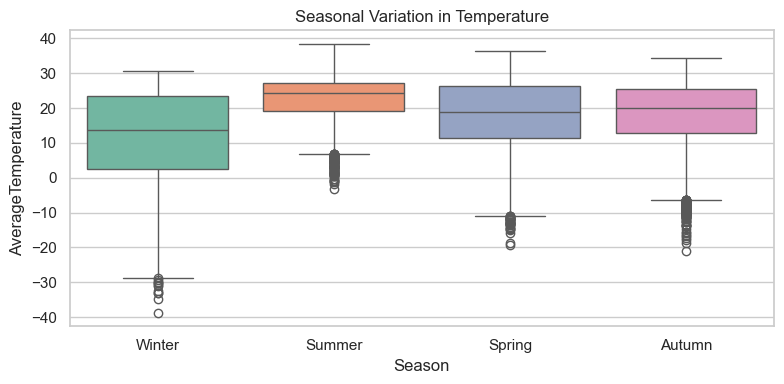

In [8]:
seasonal_sample = cleaned_df.sample(n=min(60000, len(cleaned_df)), random_state=42)
plt.figure(figsize=(8, 4))
sns.boxplot(data=seasonal_sample, x='Season', y='AverageTemperature', hue='Season', palette='Set2', legend=False)
plt.title('Seasonal Variation in Temperature')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'seasonal_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: Clear seasonal separation confirms that time-based features such as month and season are meaningful for prediction.

## Correlation Heatmap

This heatmap helps identify which numerical features move strongly with the target and with one another. It uses a sampled subset after dropping missing values so the notebook remains stable.

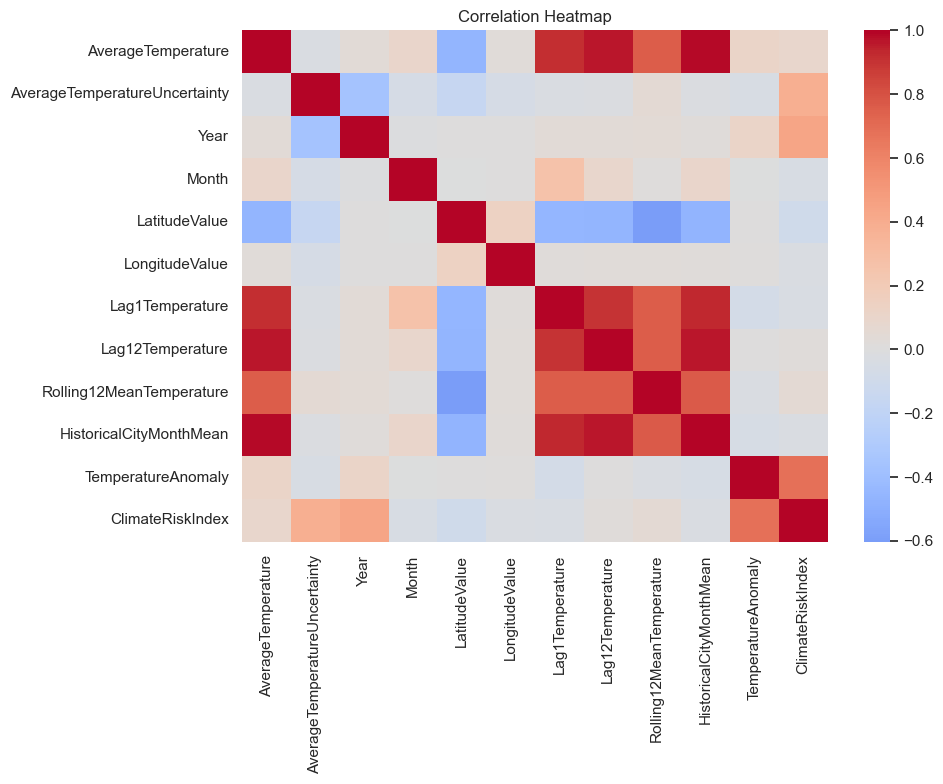

In [9]:
numeric_columns = [
    'AverageTemperature', 'AverageTemperatureUncertainty', 'Year', 'Month',
    'LatitudeValue', 'LongitudeValue', 'Lag1Temperature', 'Lag12Temperature',
    'Rolling12MeanTemperature', 'HistoricalCityMonthMean', 'TemperatureAnomaly',
    'ClimateRiskIndex'
]
correlation_source = cleaned_df[numeric_columns].dropna()
correlation_sample = correlation_source.sample(n=min(40000, len(correlation_source)), random_state=42)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_sample.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: Historical climate features such as lag values and historical city-month averages have stronger predictive relationships than simple calendar features alone.

## Country Comparison and Outlier Inspection

These charts compare selected countries and highlight the spread of temperatures across regions. Sampled plotting is used here because full boxplots would be slow and visually overcrowded.

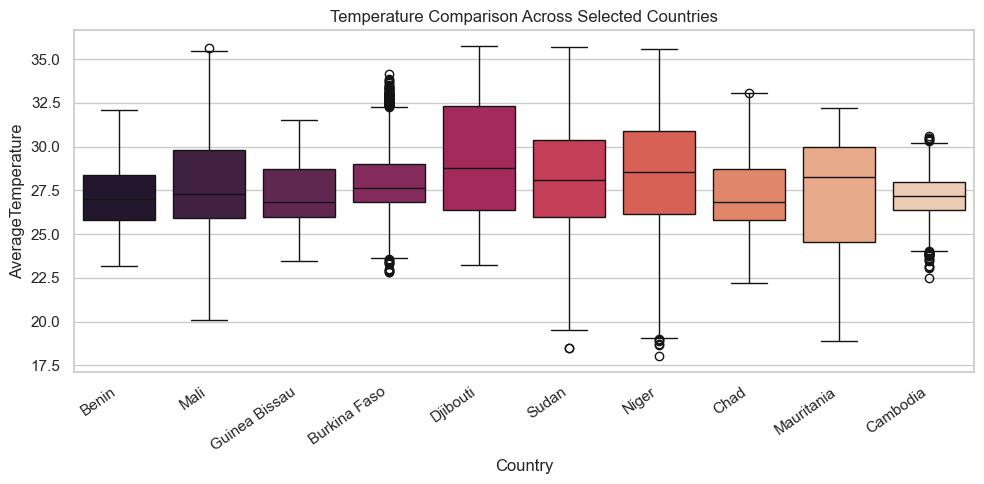

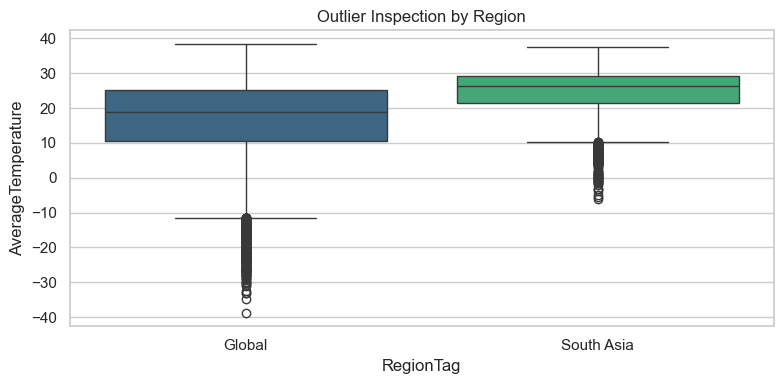

In [10]:
country_order = (
    cleaned_df.groupby('Country', observed=True)['AverageTemperature']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)
top_countries = cleaned_df[cleaned_df['Country'].isin(country_order)].copy()

plt.figure(figsize=(10, 5))
sns.boxplot(data=top_countries, x='Country', y='AverageTemperature', hue='Country', palette='rocket', legend=False)
plt.xticks(rotation=35, ha='right')
plt.title('Temperature Comparison Across Selected Countries')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'country_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=distribution_sample, x='RegionTag', y='AverageTemperature', hue='RegionTag', palette='viridis', legend=False)
plt.title('Outlier Inspection by Region')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outlier_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: Different countries and regions have very different temperature ranges, which supports the need for geographic features in the model.

## Global vs South Asia Trend

This comparison adds regional relevance and supports the novelty requirement in the project. The yearly means are calculated from the full cleaned dataset and the full South Asia subset.

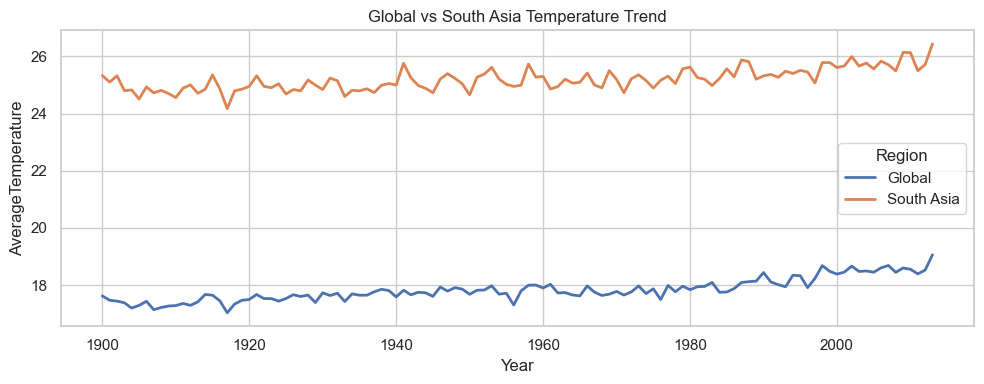

In [11]:
global_region = cleaned_df.groupby('Year', observed=True)['AverageTemperature'].mean().reset_index()
south_region = south_asia_df.groupby('Year', observed=True)['AverageTemperature'].mean().reset_index()
global_region['Region'] = 'Global'
south_region['Region'] = 'South Asia'
combined = pd.concat([global_region, south_region], ignore_index=True)

plt.figure(figsize=(10, 4))
sns.lineplot(data=combined, x='Year', y='AverageTemperature', hue='Region', linewidth=2)
plt.title('Global vs South Asia Temperature Trend')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'global_vs_south_asia_trend.png', dpi=200, bbox_inches='tight')
plt.show()

Interpretation: South Asia generally stays warmer than the global aggregate, which makes the regional case study useful for local discussion.